# Combine Reanalysis tiles by year, collate variables, and lazy load all years

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray as rxr
import rasterio as rio
import os
import dask
import matplotlib.pyplot as plt

In [5]:
from dask.distributed import Client
client = Client()

In [4]:
import os
#import xarray as xr
from pathlib import Path
from typing import List

In [2]:
sierras = gpd.read_file('../data/misc/sierras_polygon_gmba.geojson')

### Combine all the SWE files:

In [4]:
def preprocess_year(ds):

    # Select Stats = 2 slice
    ds = ds.sel({'Stats': 2})
    return ds

# def make_preprocessor(year):
#     def preprocess(ds):
#         return preprocess_year(ds, year)
#     return preprocess


def concatenate_tiles_by_year(base_dir: str, start_year: int, end_year: int) -> xr.Dataset:
    for year in range(start_year, end_year + 1):
        year_folder = Path(base_dir) / str(year)
        if not year_folder.exists():
            print(f"Skipping missing folder: {year_folder}")
            continue

        print(f"Processing {year}...")
        nc_files = sorted(Path(year_folder).glob("*SWE_SCA_POST.nc"))
        if not nc_files:
            raise FileNotFoundError(f"No .nc files found in {folder_path}")

        #preprocess = make_preprocessor(year)

        ds = xr.open_mfdataset(
        nc_files,
        #combine='by_coords',        
        preprocess=preprocess_year,
        chunks={'Latitude': 225, 'Longitude': 225, 'Day': 366, 'Stats': 5},
        #parallel=False
        )

        print(f'done loading files, now processing time dimension for {year}...')

        # Rename 'Day' to 'time' and assign datetime index
        
        start_date = pd.Timestamp(f"{year - 1}-10-01")

        # Get Day values
        day_offsets = ds['Day'].values  # e.g., [0, 1, ..., 364]

        # Convert to datetime by adding offsets to Oct 1
        dates = pd.to_datetime([start_date + pd.Timedelta(days=int(d)) for d in day_offsets])

        # Add as new time coordinate and swap dimensions
        ds = ds.assign_coords(time=("Day", dates))
        ds = ds.swap_dims({"Day": "time"})

        ds.rio.write_crs('EPSG:4326', inplace=True)
        ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
        ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
        ds['SWE_Post'] = ds['SWE_Post'].T
        ds['SCA_Post'] = ds['SCA_Post'].T

        print(f'done processing time dimension, now saving out file for {year}...')

        ds.to_netcdf(f"{year_folder}/SWE_SCA_POST_{year}.nc", mode='w')

    
    #return ds

In [5]:
concatenate_tiles_by_year("../swe_reanalysis_pca/data/download/", 1990, 1991)

Processing 1990...
done loading files, now processing time dimension for 1990...
done processing time dimension, now saving out file for 1990...
Processing 1991...
done loading files, now processing time dimension for 1991...
done processing time dimension, now saving out file for 1991...


In [23]:
concatenate_tiles_by_year("../swe_reanalysis_pca/data/download/", 2004, 2021)

Processing 2004...
done loading files, now processing time dimension for 2004...
done processing time dimension, now saving out file for 2004...
Processing 2005...
done loading files, now processing time dimension for 2005...
done processing time dimension, now saving out file for 2005...
Processing 2006...
done loading files, now processing time dimension for 2006...
done processing time dimension, now saving out file for 2006...
Processing 2007...
done loading files, now processing time dimension for 2007...
done processing time dimension, now saving out file for 2007...
Processing 2008...
done loading files, now processing time dimension for 2008...
done processing time dimension, now saving out file for 2008...
Processing 2009...
done loading files, now processing time dimension for 2009...
done processing time dimension, now saving out file for 2009...
Processing 2010...
done loading files, now processing time dimension for 2010...
done processing time dimension, now saving out fi

2025-10-18 11:51:32,982 - distributed.worker - ERROR - failed during get data with tcp://127.0.0.1:63716 -> tcp://127.0.0.1:63713
Traceback (most recent call last):
  File "/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/tornado/iostream.py", line 962, in _handle_write
    num_bytes = self.write_to_fd(self._write_buffer.peek(size))
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/tornado/iostream.py", line 1121, in write_to_fd
    return self.socket.send(data)  # type: ignore
           ^^^^^^^^^^^^^^^^^^^^^^
OSError: [Errno 55] No buffer space available

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/distributed/worker.py", line 1795, in get_data
    response = await comm.read(deserialize

Processing 2011...
done loading files, now processing time dimension for 2011...
done processing time dimension, now saving out file for 2011...
Processing 2012...
done loading files, now processing time dimension for 2012...
done processing time dimension, now saving out file for 2012...
Processing 2013...
done loading files, now processing time dimension for 2013...
done processing time dimension, now saving out file for 2013...
Processing 2014...
done loading files, now processing time dimension for 2014...
done processing time dimension, now saving out file for 2014...


2025-10-18 12:11:06,573 - distributed.worker - ERROR - failed during get data with tcp://127.0.0.1:63716 -> tcp://127.0.0.1:63708
Traceback (most recent call last):
  File "/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/tornado/iostream.py", line 962, in _handle_write
    num_bytes = self.write_to_fd(self._write_buffer.peek(size))
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/tornado/iostream.py", line 1121, in write_to_fd
    return self.socket.send(data)  # type: ignore
           ^^^^^^^^^^^^^^^^^^^^^^
OSError: [Errno 55] No buffer space available

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/distributed/worker.py", line 1795, in get_data
    response = await comm.read(deserialize

Processing 2015...
done loading files, now processing time dimension for 2015...
done processing time dimension, now saving out file for 2015...
Processing 2016...
done loading files, now processing time dimension for 2016...
done processing time dimension, now saving out file for 2016...


2025-10-18 12:19:10,196 - distributed.worker - ERROR - failed during get data with tcp://127.0.0.1:63708 -> tcp://127.0.0.1:63713
Traceback (most recent call last):
  File "/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/tornado/iostream.py", line 962, in _handle_write
    num_bytes = self.write_to_fd(self._write_buffer.peek(size))
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/tornado/iostream.py", line 1121, in write_to_fd
    return self.socket.send(data)  # type: ignore
           ^^^^^^^^^^^^^^^^^^^^^^
OSError: [Errno 55] No buffer space available

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/distributed/worker.py", line 1795, in get_data
    response = await comm.read(deserialize

Processing 2017...
done loading files, now processing time dimension for 2017...
done processing time dimension, now saving out file for 2017...
Processing 2018...
done loading files, now processing time dimension for 2018...
done processing time dimension, now saving out file for 2018...
Processing 2019...
done loading files, now processing time dimension for 2019...
done processing time dimension, now saving out file for 2019...
Processing 2020...
done loading files, now processing time dimension for 2020...
done processing time dimension, now saving out file for 2020...
Processing 2021...
done loading files, now processing time dimension for 2021...
done processing time dimension, now saving out file for 2021...


In [24]:
concatenate_tiles_by_year("../swe_reanalysis_pca/data/download/", 1985, 1989)

Processing 1985...
done loading files, now processing time dimension for 1985...
done processing time dimension, now saving out file for 1985...
Processing 1986...
done loading files, now processing time dimension for 1986...
done processing time dimension, now saving out file for 1986...
Processing 1987...
done loading files, now processing time dimension for 1987...
done processing time dimension, now saving out file for 1987...
Processing 1988...
done loading files, now processing time dimension for 1988...
done processing time dimension, now saving out file for 1988...
Processing 1989...
done loading files, now processing time dimension for 1989...
done processing time dimension, now saving out file for 1989...


### Combine all the SD files:

In [7]:
def preprocess_year(ds):

    # Select Stats = 2 slice
    ds = ds.sel({'Stats': 2})
    return ds

# def make_preprocessor(year):
#     def preprocess(ds):
#         return preprocess_year(ds, year)
#     return preprocess


def concatenate_tiles_by_year_sd(base_dir: str, start_year: int, end_year: int) -> xr.Dataset:
    for year in range(start_year, end_year + 1):
        year_folder = Path(base_dir) / str(year)
        if not year_folder.exists():
            print(f"Skipping missing folder: {year_folder}")
            continue

        print(f"Processing {year}...")
        nc_files = sorted(Path(year_folder).glob("*SD_POST.nc"))
        if not nc_files:
            raise FileNotFoundError(f"No .nc files found in {folder_path}")

        #preprocess = make_preprocessor(year)

        ds = xr.open_mfdataset(
        nc_files,
        #combine='by_coords',        
        preprocess=preprocess_year,
        chunks={'Latitude': 225, 'Longitude': 225, 'Day': 366, 'Stats': 5},
        #parallel=False
        )

        print(f'done loading files, now processing time dimension for {year}...')

        # Rename 'Day' to 'time' and assign datetime index
        
        start_date = pd.Timestamp(f"{year - 1}-10-01")

        # Get Day values
        day_offsets = ds['Day'].values  # e.g., [0, 1, ..., 364]

        # Convert to datetime by adding offsets to Oct 1
        dates = pd.to_datetime([start_date + pd.Timedelta(days=int(d)) for d in day_offsets])

        # Add as new time coordinate and swap dimensions
        ds = ds.assign_coords(time=("Day", dates))
        ds = ds.swap_dims({"Day": "time"})

        ds.rio.write_crs('EPSG:4326', inplace=True)
        ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
        ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
        ds['SD_Post'] = ds['SD_Post'].T


        print(f'done processing time dimension, now saving out file for {year}...')

        ds.to_netcdf(f"{year_folder}/SD_POST_{year}.nc", mode='w')

    
    #return ds

In [25]:
concatenate_tiles_by_year_sd("../swe_reanalysis_pca/data/download/", 1985, 2021)

Processing 1985...
done loading files, now processing time dimension for 1985...
done processing time dimension, now saving out file for 1985...
Processing 1986...
done loading files, now processing time dimension for 1986...
done processing time dimension, now saving out file for 1986...
Processing 1987...
done loading files, now processing time dimension for 1987...
done processing time dimension, now saving out file for 1987...
Processing 1988...
done loading files, now processing time dimension for 1988...
done processing time dimension, now saving out file for 1988...
Processing 1989...
done loading files, now processing time dimension for 1989...
done processing time dimension, now saving out file for 1989...
Processing 1990...
done loading files, now processing time dimension for 1990...
done processing time dimension, now saving out file for 1990...
Processing 1991...
done loading files, now processing time dimension for 1991...
done processing time dimension, now saving out fi

#### Look at one of the yearly files:

In [26]:
swe_sca_2020 = xr.open_dataset('../swe_reanalysis_pca/data/download/2020/SWE_SCA_POST_2020.nc')

<Axes: title={'center': 'time = 2020-04-01'}, xlabel='Longitude', ylabel='Latitude'>

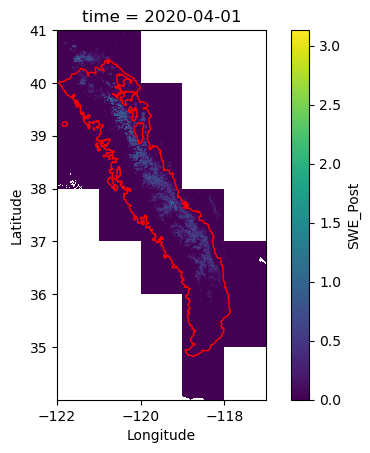

In [36]:
fig, ax = plt.subplots()
swe_sca_2020.SWE_Post.T.sel(time='2020-04-01').plot(ax=ax)
sierras.plot(ax=ax, facecolor='none', edgecolor='red')

In [40]:
swe_sca_2020

<xarray.Dataset> Size: 5GB
Dimensions:    (time: 366, Longitude: 1125, Latitude: 1575)
Coordinates:
  * Latitude   (Latitude) float32 6kB 34.0 34.01 34.01 ... 40.99 40.99 41.0
  * Longitude  (Longitude) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0
  * time       (time) datetime64[ns] 3kB 2019-10-01 2019-10-02 ... 2020-09-30
Data variables:
    SWE_Post   (time, Longitude, Latitude) float32 3GB ...
    SCA_Post   (time, Longitude, Latitude) float32 3GB ...

In [33]:
sd_2020 = xr.open_dataset('../swe_reanalysis_pca/data/download/2020/SD_POST_2020.nc')

In [34]:
sd_2020

<xarray.Dataset> Size: 3GB
Dimensions:      (y: 1575, x: 1125, time: 366)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 3kB 2019-10-01 2019-10-02 ... 2020-09-30
    spatial_ref  int64 8B ...
Data variables:
    SD_Post      (y, x, time) float32 3GB ...

### Open all the annual files as one using openmfdataset:

In [41]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(1985, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds['SD_Post'] = sd_ds['SD_Post']

swe_sca_ds.rio.write_crs('EPSG:4326', inplace=True)
# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds['SWE_Post'] = swe_sca_ds['SWE_Post'].T
swe_sca_ds['SCA_Post'] = swe_sca_ds['SCA_Post'].T
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

In [42]:
swe_sca_ds

<xarray.Dataset> Size: 287GB
Dimensions:      (y: 1575, x: 1125, time: 13514)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (y, x, time) float32 96GB dask.array<chunksize=(263, 188, 61), meta=np.ndarray>
    SCA_Post     (y, x, time) float32 96GB dask.array<chunksize=(263, 188, 61), meta=np.ndarray>
    SD_Post      (y, x, time) float32 96GB dask.array<chunksize=(263, 188, 61), meta=np.ndarray>

In [26]:
#swe_sca_ds.to_netcdf('../data/reanalysis/swe_sca_sd_1985_2021.nc', mode='w')

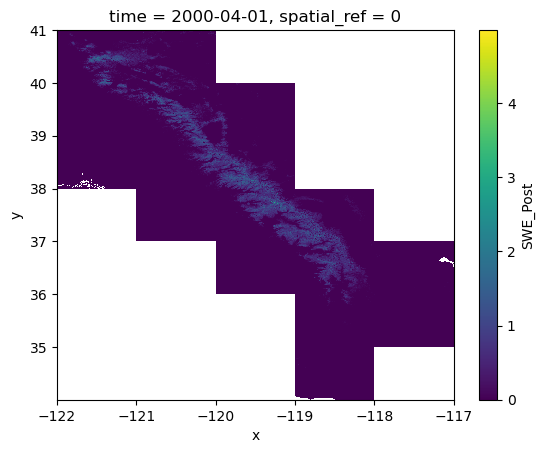

In [38]:
swe_sca_ds.SWE_Post.sel(time='2000-04-01').plot()

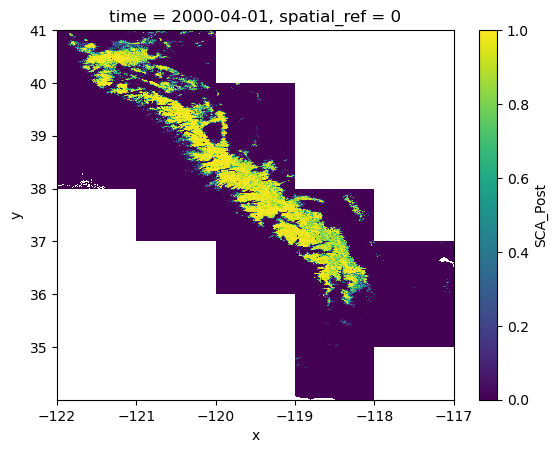

In [39]:
swe_sca_ds.SCA_Post.sel(time='2000-04-01').plot()

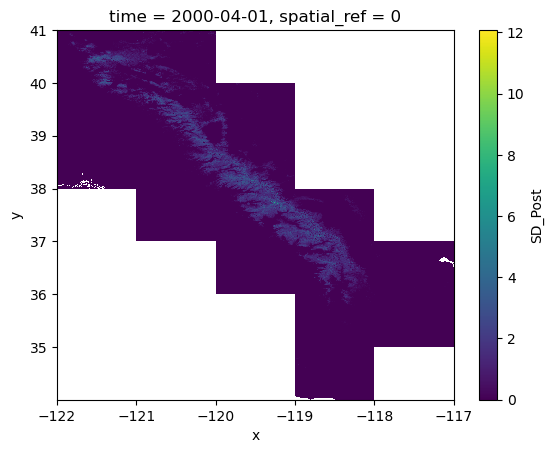

In [43]:
swe_sca_ds.SD_Post.sel(time='2000-04-01').plot()

### Clip the reanalysis to the sierras outline

In [32]:
swe_sca_ds

<xarray.Dataset> Size: 287GB
Dimensions:      (Latitude: 1575, Longitude: 1125, time: 13514, y: 1575, x: 1125)
Coordinates:
  * Latitude     (Latitude) float32 6kB 34.0 34.01 34.01 ... 40.99 40.99 41.0
  * Longitude    (Longitude) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (Latitude, Longitude, time) float32 96GB dask.array<chunksize=(263, 188, 61), meta=np.ndarray>
    SCA_Post     (Latitude, Longitude, time) float32 96GB dask.array<chunksize=(263, 188, 61), meta=np.ndarray>
    SD_Post      (time, x, y) float32 96GB dask.array<chunksize=(61, 188, 263), meta=np.ndarray>

In [44]:
print(swe_sca_ds.dims)
print(swe_sca_ds.coords)
print(swe_sca_ds.data_vars) # If it's a Dataset

FrozenMappingWarningOnValuesAccess({'y': 1575, 'x': 1125, 'time': 13514})
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post  (y, x, time) float32 96GB dask.array<chunksize=(263, 188, 61), meta=np.ndarray>
    SCA_Post  (y, x, time) float32 96GB dask.array<chunksize=(263, 188, 61), meta=np.ndarray>
    SD_Post   (y, x, time) float32 96GB dask.array<chunksize=(263, 188, 61), meta=np.ndarray>


In [45]:
swe_sca_ds_clipped = swe_sca_ds.rio.clip(sierras.geometry)

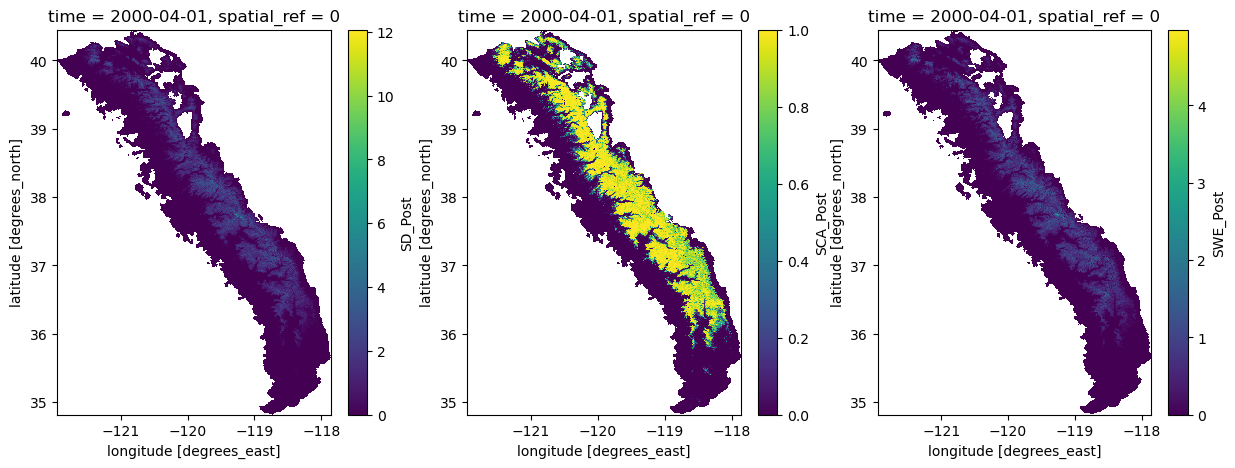

2025-10-27 23:52:44,083 - tornado.application - ERROR - Exception in callback <bound method SystemMonitor.update of <SystemMonitor: cpu: 2 memory: 36 MB fds: 32>>
Traceback (most recent call last):
  File "/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/tornado/ioloop.py", line 945, in _run
    val = self.callback()
          ^^^^^^^^^^^^^^^
  File "/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/distributed/system_monitor.py", line 168, in update
    net_ioc = psutil.net_io_counters()
              ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/psutil/__init__.py", line 2148, in net_io_counters
    rawdict = _psplatform.net_io_counters()
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: [Errno 12] Cannot allocate memory
2025-11-01 17:23:02,063 - tornado.application - ERROR - Exception in callback <bound method SystemMonitor.update of

In [48]:
fig, ax = plt.subplots(1,3, figsize=(15,5))
swe_sca_ds_clipped.SD_Post.sel(time='2000-04-01').plot(ax=ax[0])
swe_sca_ds_clipped.SCA_Post.sel(time='2000-04-01').plot(ax=ax[1])
swe_sca_ds_clipped.SWE_Post.sel(time='2000-04-01').plot(ax=ax[2])

## Load a single year for testing (2021):

### Load and process the snow depth reanalysis data over the Sierras:

In [6]:
download_dir = f'../swe_reanalysis_pca/data/download/2021/'

## get list of netcdf files ##
dir_lst = os.listdir(download_dir)[0]

In [47]:
download_dir = f'../swe_reanalysis_pca/data/download/2021/'

## get list of netcdf files ##
dir_lst = os.listdir(download_dir)
nclist = [download_dir + x for x in dir_lst if "SD_POST.nc" in x]
nclist.sort()

## concatenate netcdf files ##
#dask.config.set({"array.slicing.split_large_chunks": True})

def preprocess(ds):
    ds.rio.write_crs('EPSG:4326',inplace = True)
    ds = ds.rename({'Latitude':'y','Longitude':'x'})
    ds = ds.rio.set_spatial_dims('y','x',inplace=True)
    ds['SD_Post'] = ds['SD_Post'].T
    return ds.SD_Post.sel({'Stats': 2}).to_dataset()

## load dataset ##
ds = xr.open_mfdataset(nclist,chunks=None, combine = 'by_coords',preprocess = preprocess)
ds.load()

<xarray.Dataset> Size: 3GB
Dimensions:      (y: 1575, x: 1125, Day: 365)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
    spatial_ref  int64 8B 0
Dimensions without coordinates: Day
Data variables:
    SD_Post      (y, x, Day) float32 3GB nan nan nan nan nan ... nan nan nan nan

In [77]:
# Switch the order of dimensions to make subsetting by 'Day' easier:

ds_t1 = ds.transpose("y", "x", "Day")[["Day", "y", "x", "SD_Post"]]
ds_t = ds_t1.transpose('Day', 'y', 'x')
ds_t

<xarray.Dataset> Size: 3GB
Dimensions:      (Day: 365, y: 1575, x: 1125)
Coordinates:
  * Day          (Day) int64 3kB 0 1 2 3 4 5 6 7 ... 358 359 360 361 362 363 364
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
    spatial_ref  int64 8B 0
Data variables:
    SD_Post      (Day, y, x) float32 3GB nan nan nan nan nan ... nan nan nan nan

<Axes: title={'center': 'Day = 150, spatial_ref = 0'}, xlabel='x', ylabel='y'>

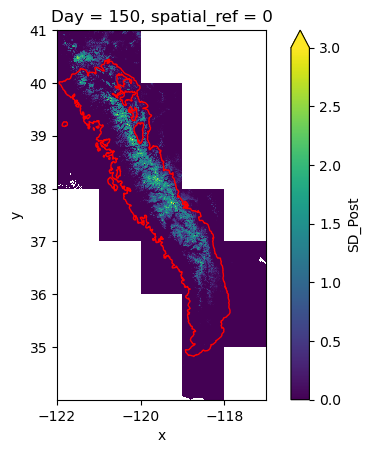

In [81]:
# Plot the snow depth data

fig, ax = plt.subplots()

ds_t.SD_Post[150].plot(ax=ax, vmax=3)
sierras.plot(facecolor='none', edgecolor='r', ax=ax)

### Load and process the SWE and fSCA reanalysis data over the Sierra:

In [83]:
download_dir = f'../swe_reanalysis_pca/data/download/2021/'

## get list of netcdf files ##
dir_lst = os.listdir(download_dir)
nclist = [download_dir + x for x in dir_lst if "SCA_POST.nc" in x]
nclist.sort()

## concatenate netcdf files ##
#dask.config.set({"array.slicing.split_large_chunks": True})

def preprocess(ds):
    ds.rio.write_crs('EPSG:4326',inplace = True)
    ds = ds.rename({'Latitude':'y','Longitude':'x'})
    ds = ds.rio.set_spatial_dims('y','x',inplace=True)
    ds['SCA_Post'] = ds['SCA_Post'].T
    return ds.SCA_Post.sel({'Stats': 2}).to_dataset()

## load dataset ##
ds_sca = xr.open_mfdataset(nclist,chunks=None, combine = 'by_coords',preprocess = preprocess)
ds_sca.load()



# download_dir = f'../swe_reanalysis_pca/data/download/2021/'

# ## get list of netcdf files ##
# dir_lst = os.listdir(download_dir)
# nclist = [download_dir + x for x in dir_lst if "SCA_POST.nc" in x]
# nclist.sort()

# ## concatenate netcdf files ##
# #dask.config.set({"array.slicing.split_large_chunks": True})

# def preprocess(ds_sd):
#     return ds_sd.SCA_Post.sel({'Stats': 2}).to_dataset()

# ## load dataset ##
# ds_sd = xr.open_mfdataset(nclist,chunks=None, combine = 'by_coords',preprocess = preprocess)
# ds_sd.load()

<xarray.Dataset> Size: 3GB
Dimensions:      (y: 1575, x: 1125, Day: 365)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
    spatial_ref  int64 8B 0
Dimensions without coordinates: Day
Data variables:
    SCA_Post     (y, x, Day) float32 3GB nan nan nan nan nan ... nan nan nan nan

In [86]:
# Switch the order of dimensions to make subsetting by 'Day' easier:

ds_sca_t1 = ds_sca.transpose("y", "x", "Day")[["Day", "y", "x", "SCA_Post"]]
ds_sca_t = ds_sca_t1.transpose('Day', 'y', 'x')
ds_sca_t

<xarray.Dataset> Size: 3GB
Dimensions:      (Day: 365, y: 1575, x: 1125)
Coordinates:
  * Day          (Day) int64 3kB 0 1 2 3 4 5 6 7 ... 358 359 360 361 362 363 364
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
    spatial_ref  int64 8B 0
Data variables:
    SCA_Post     (Day, y, x) float32 3GB nan nan nan nan nan ... nan nan nan nan

<Axes: title={'center': 'Day = 150, spatial_ref = 0'}, xlabel='x', ylabel='y'>

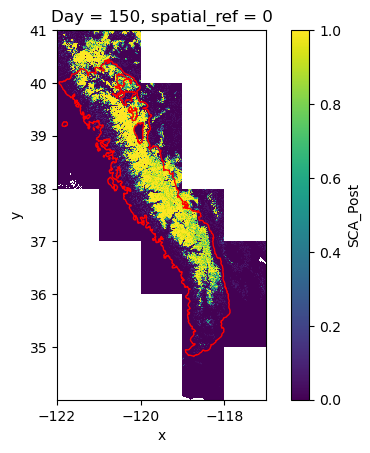

In [88]:
fig, ax = plt.subplots()

ds_sca_t.SCA_Post[150].plot(ax=ax)
sierras.plot(facecolor='none', edgecolor='r', ax=ax)

In [84]:
download_dir = f'../swe_reanalysis_pca/data/download/2021/'

## get list of netcdf files ##
dir_lst = os.listdir(download_dir)
nclist = [download_dir + x for x in dir_lst if "SCA_POST.nc" in x]
nclist.sort()

## concatenate netcdf files ##
#dask.config.set({"array.slicing.split_large_chunks": True})

def preprocess(ds):
    ds.rio.write_crs('EPSG:4326',inplace = True)
    ds = ds.rename({'Latitude':'y','Longitude':'x'})
    ds = ds.rio.set_spatial_dims('y','x',inplace=True)
    ds['SWE_Post'] = ds['SWE_Post'].T
    return ds.SWE_Post.sel({'Stats': 2}).to_dataset()

## load dataset ##
ds_swe = xr.open_mfdataset(nclist,chunks=None, combine = 'by_coords',preprocess = preprocess)
ds_swe.load()

<xarray.Dataset> Size: 3GB
Dimensions:      (y: 1575, x: 1125, Day: 365)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
    spatial_ref  int64 8B 0
Dimensions without coordinates: Day
Data variables:
    SWE_Post     (y, x, Day) float32 3GB nan nan nan nan nan ... nan nan nan nan

In [87]:
# Switch the order of dimensions to make subsetting by 'Day' easier:

ds_swe_t1 = ds_swe.transpose("y", "x", "Day")[["Day", "y", "x", "SWE_Post"]]
ds_swe_t = ds_swe_t1.transpose('Day', 'y', 'x')
ds_swe_t

<xarray.Dataset> Size: 3GB
Dimensions:      (Day: 365, y: 1575, x: 1125)
Coordinates:
  * Day          (Day) int64 3kB 0 1 2 3 4 5 6 7 ... 358 359 360 361 362 363 364
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (Day, y, x) float32 3GB nan nan nan nan nan ... nan nan nan nan

<Axes: title={'center': 'Day = 150, spatial_ref = 0'}, xlabel='x', ylabel='y'>

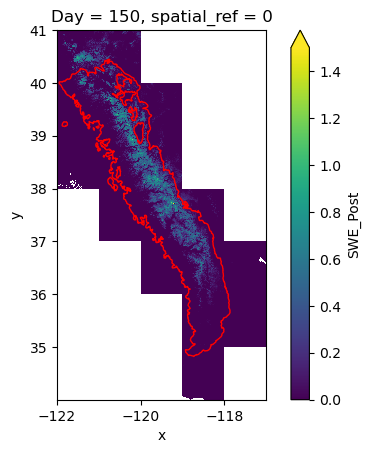

In [90]:
fig, ax = plt.subplots()

ds_swe_t.SWE_Post[150].plot(ax=ax, vmax=1.5)
sierras.plot(facecolor='none', edgecolor='r', ax=ax)

### Combine the three variables into one dataset:

In [91]:
merged_ds = xr.combine_by_coords([ds_t, ds_sca_t, ds_swe_t])

In [92]:
merged_ds

<xarray.Dataset> Size: 8GB
Dimensions:      (Day: 365, y: 1575, x: 1125)
Coordinates:
  * Day          (Day) int64 3kB 0 1 2 3 4 5 6 7 ... 358 359 360 361 362 363 364
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
    spatial_ref  int64 8B 0
Data variables:
    SD_Post      (Day, y, x) float32 3GB nan nan nan nan nan ... nan nan nan nan
    SCA_Post     (Day, y, x) float32 3GB nan nan nan nan nan ... nan nan nan nan
    SWE_Post     (Day, y, x) float32 3GB nan nan nan nan nan ... nan nan nan nan

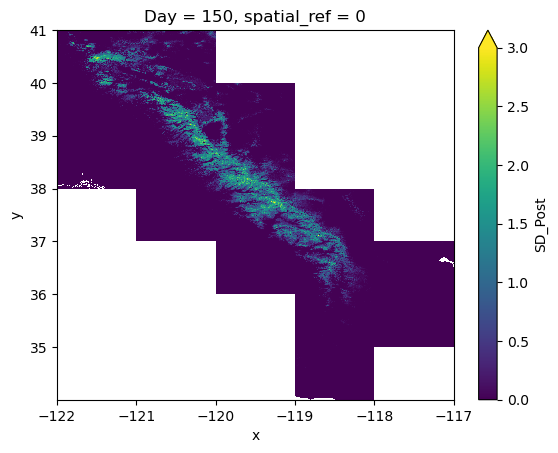

In [94]:
merged_ds.SD_Post[150].plot(vmax=3)

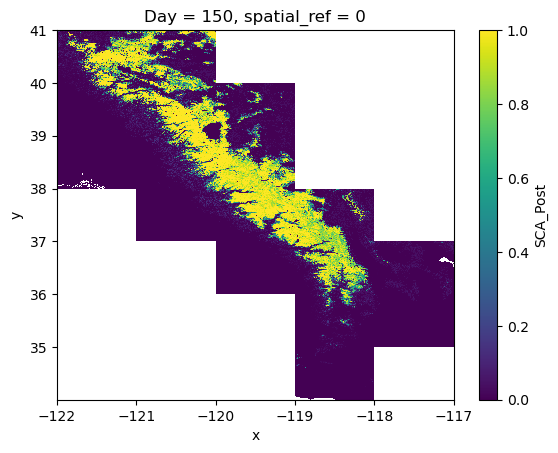

In [95]:
merged_ds.SCA_Post[150].plot()

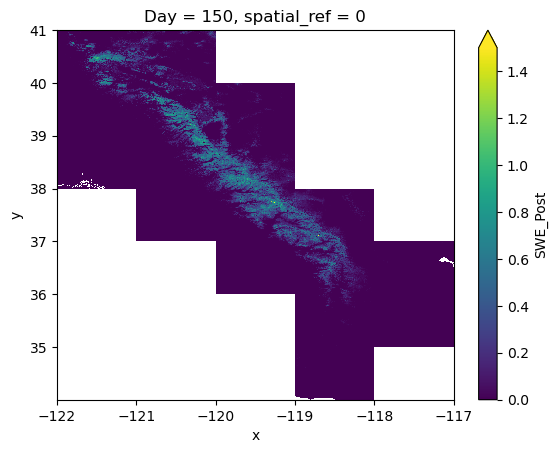

In [96]:
merged_ds.SWE_Post[150].plot(vmax=1.5)

In [26]:
# clip the reanalysis to the sierras outline

# Match up dates between DOY in the reanalysis and acquisition day of icesat-2: add doy to icesat-2

# Go through notebook of IS2 compared to reanalysis in tuolumne using the data from the 2021 sierras. 
# Include appropriate metrics from Zachs paper

In [97]:
# clip the reanalysis to the sierras outline

ds_sierra = merged_ds.rio.clip(sierras.geometry)

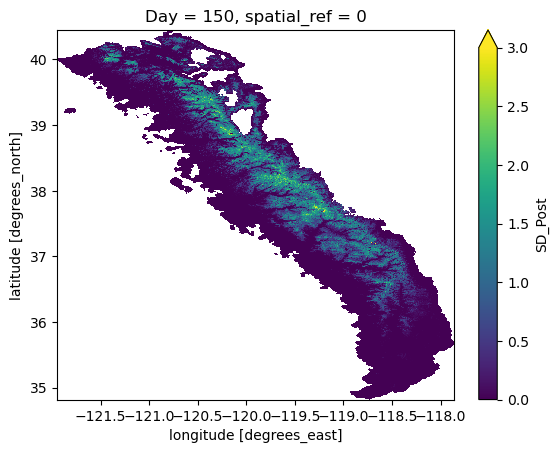

In [98]:
ds_sierra.SD_Post[150].plot(vmax=3)

In [74]:
pwd

'/Users/hannah/Documents/Grad_Documents/Research/analog_snowmapping/notebooks'

In [99]:
ds_sierra.to_netcdf('../data/reanalysis/reanalysis_sierras_processed_2021.nc')